Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ All libraries imported successfully


╔==============================================================================╗
║                      AIR QUALITY NO₂ DOWNSCALING — DELHI                     ║
║                ML Gap Filling | Spatial Lag | No Temporal Lags               ║
║                 TEMPORAL + SPATIAL VALIDATION | 8-Metric Suite               ║
╚==============================================================================╝

Start: 2026-02-17 08:03:53

STEP 1: LOADING DATA
✓ Data loaded successfully
  - Rows: 14,274
  - Columns: 15
  - Stations: 39
✓ Date converted to datetime
  - Date range: 2024-01-01 00:00:00 to 2024-12-31 00:00:00
  - Total days: 365

✓ Sample of your data:
       station       lat        lon       date  groundtruth_no2  tropospheric_no2  population_density  night_light       u10       v10  wind_speed  temperature_2m_C  s

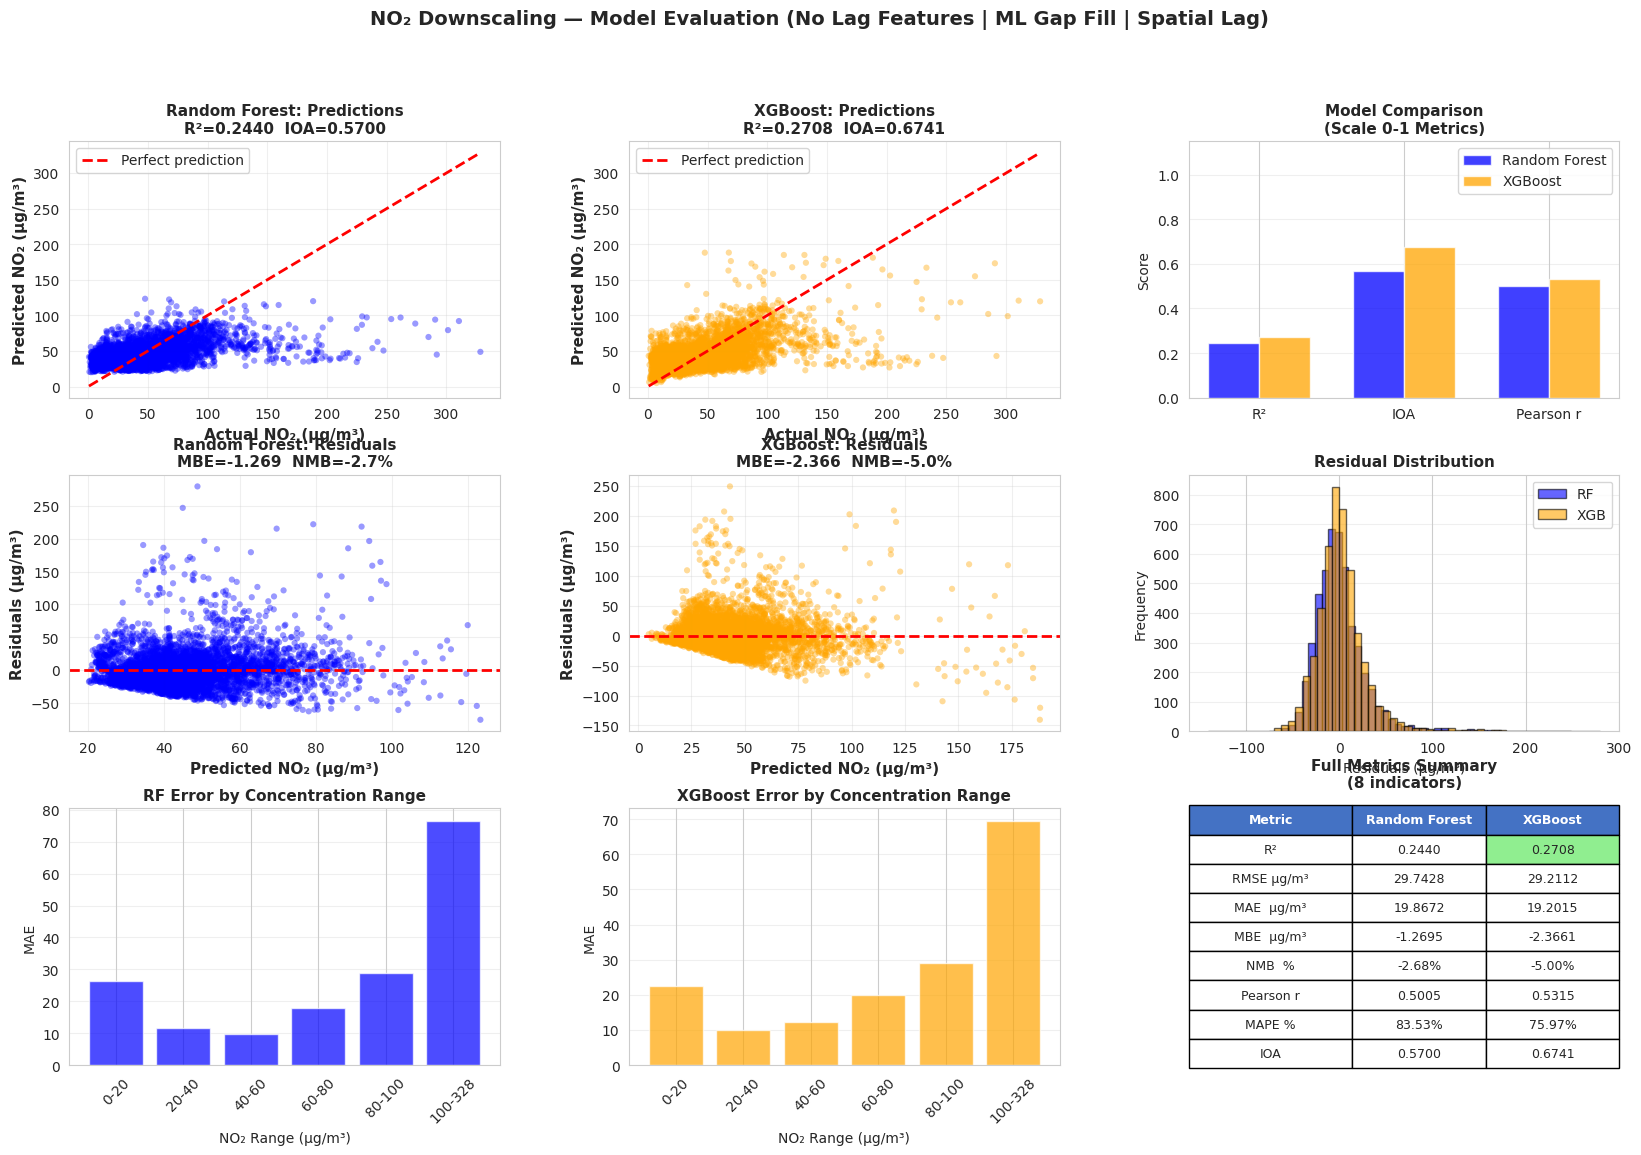

✓ Saved: random_forest_feature_importance.png


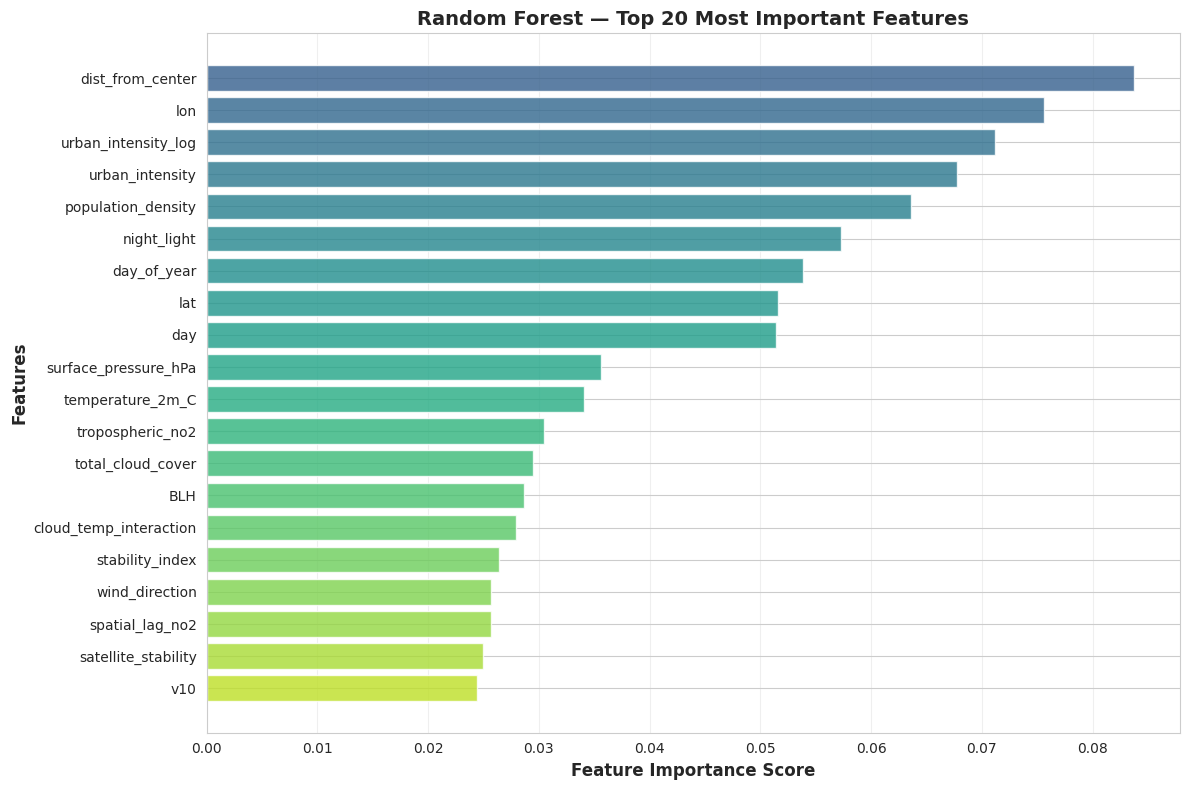


Top 10 — Random Forest:
   1. dist_from_center                        : 0.0837
   2. lon                                     : 0.0756
   3. urban_intensity_log                     : 0.0712
   4. urban_intensity                         : 0.0678
   5. population_density                      : 0.0636
   6. night_light                             : 0.0573
   7. day_of_year                             : 0.0538
   8. lat                                     : 0.0516
   9. day                                     : 0.0514
  10. surface_pressure_hPa                    : 0.0356
✓ Saved: xgboost_feature_importance.png


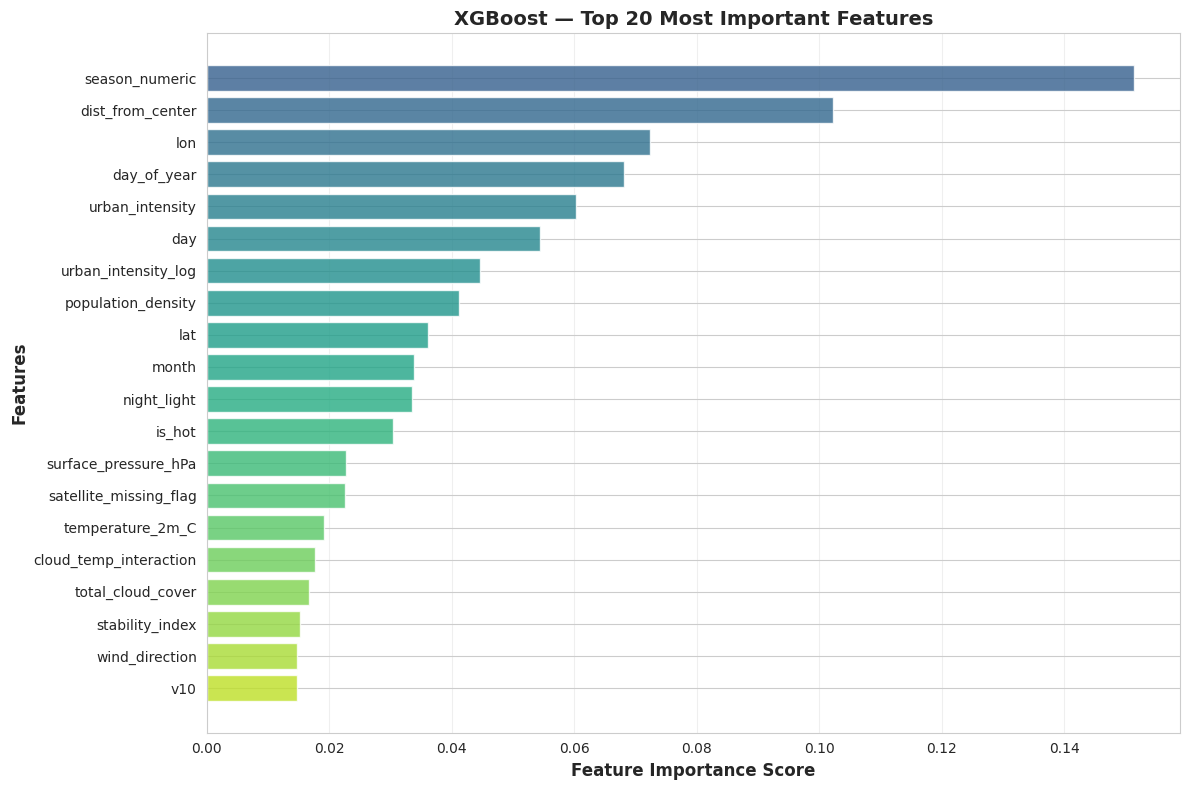


Top 10 — XGBoost:
   1. season_numeric                          : 0.1513
   2. dist_from_center                        : 0.1023
   3. lon                                     : 0.0724
   4. day_of_year                             : 0.0682
   5. urban_intensity                         : 0.0603
   6. day                                     : 0.0545
   7. urban_intensity_log                     : 0.0446
   8. population_density                      : 0.0412
   9. lat                                     : 0.0362
  10. month                                   : 0.0339

STEP 7B: FEATURE IMPORTANCE ANALYSIS
✓ Saved: feature_importance_analysis.png


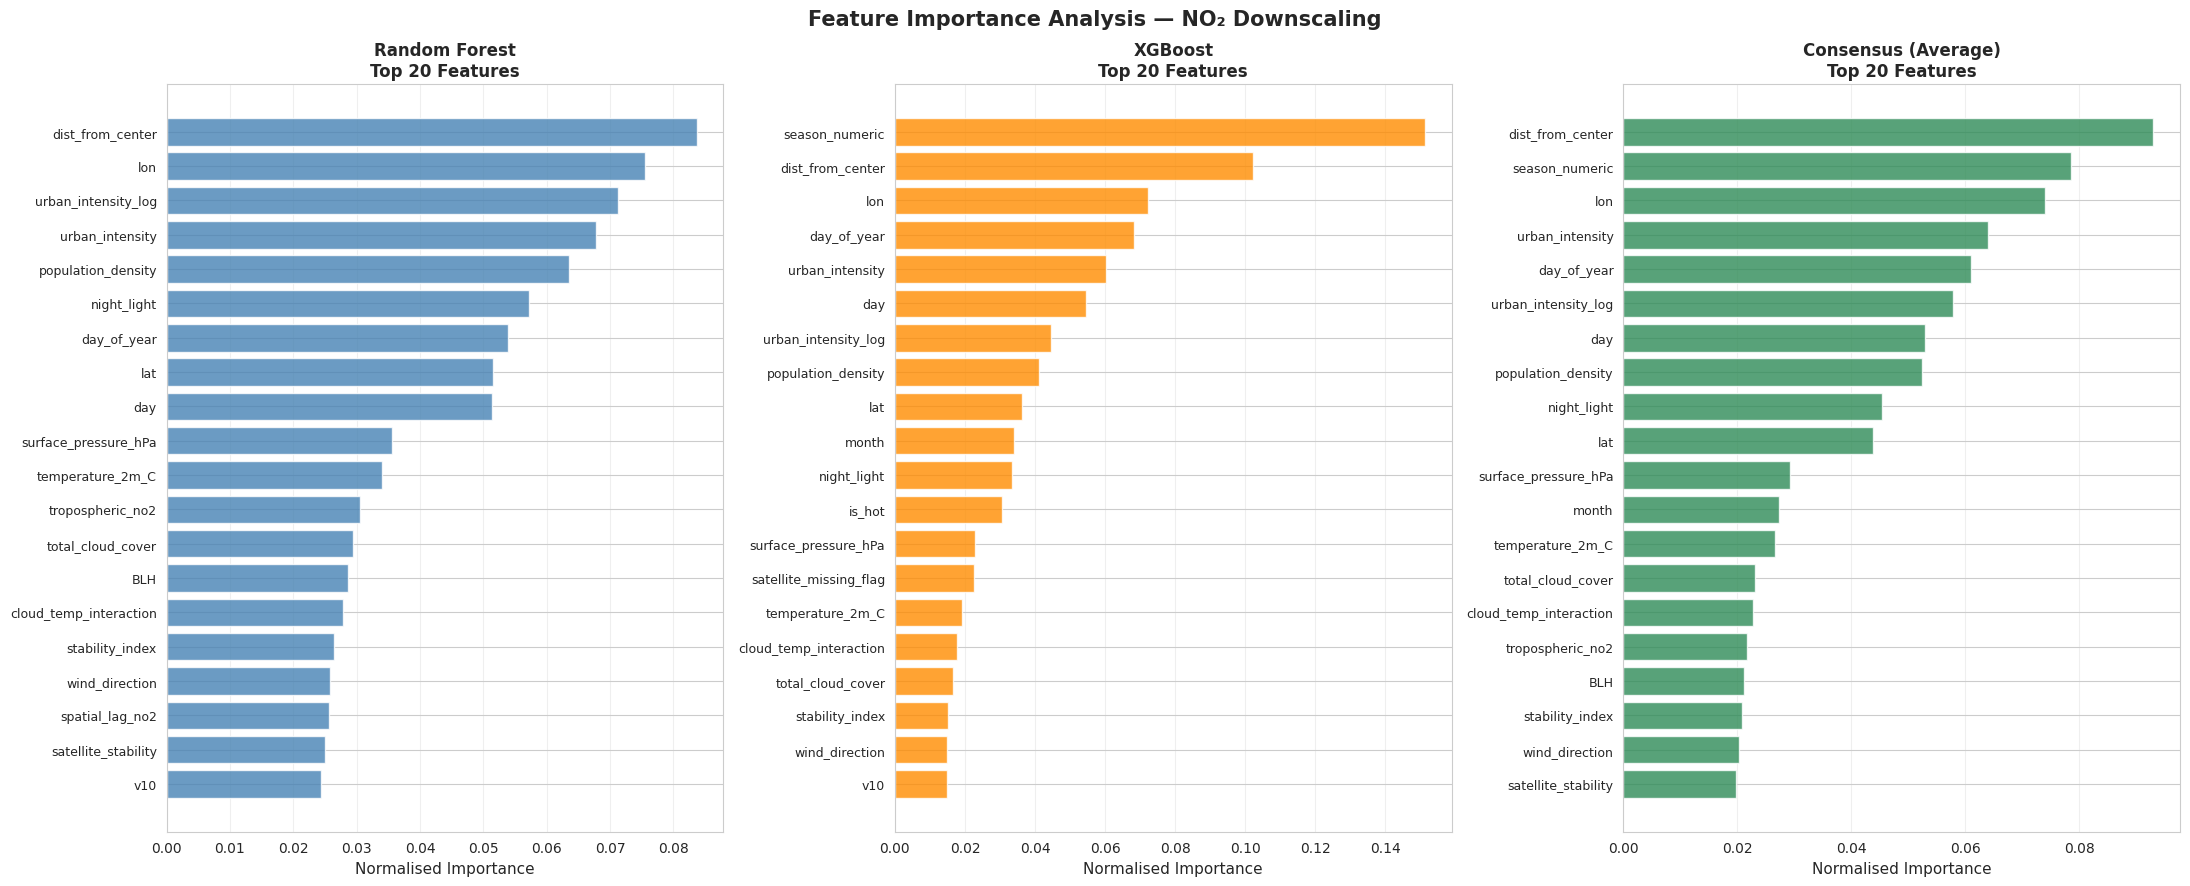


  Top 10 Consensus Features:
     1. dist_from_center                        : 0.0930
     2. season_numeric                          : 0.0785
     3. lon                                     : 0.0740
     4. urban_intensity                         : 0.0640
     5. day_of_year                             : 0.0610
     6. urban_intensity_log                     : 0.0579
     7. day                                     : 0.0530
     8. population_density                      : 0.0524
     9. night_light                             : 0.0454
    10. lat                                     : 0.0439

STEP 8: SAVING MODELS TO GOOGLE DRIVE
✓ Saved: /content/drive/MyDrive/MAJOR_PROJECT/trained_models/random_forest_no2_model.pkl
✓ Saved: /content/drive/MyDrive/MAJOR_PROJECT/trained_models/xgboost_no2_model.pkl

✓ All models saved to /content/drive/MyDrive/MAJOR_PROJECT/trained_models

To reload:
  import pickle
  with open('/content/drive/MyDrive/MAJOR_PROJECT/trained_models/xgboost_no2_model.pkl

✅ /content/drive/MyDrive/MAJOR_PROJECT/GeoTIFF_Daily/NO2_500m_20240202.tif
✅ /content/drive/MyDrive/MAJOR_PROJECT/GeoTIFF_Daily/NO2_500m_20240203.tif
✅ /content/drive/MyDrive/MAJOR_PROJECT/GeoTIFF_Daily/NO2_500m_20240204.tif
✅ /content/drive/MyDrive/MAJOR_PROJECT/GeoTIFF_Daily/NO2_500m_20240205.tif
✅ /content/drive/MyDrive/MAJOR_PROJECT/GeoTIFF_Daily/NO2_500m_20240206.tif
✅ /content/drive/MyDrive/MAJOR_PROJECT/GeoTIFF_Daily/NO2_500m_20240207.tif
✅ /content/drive/MyDrive/MAJOR_PROJECT/GeoTIFF_Daily/NO2_500m_20240208.tif
✅ /content/drive/MyDrive/MAJOR_PROJECT/GeoTIFF_Daily/NO2_500m_20240209.tif
✅ /content/drive/MyDrive/MAJOR_PROJECT/GeoTIFF_Daily/NO2_500m_20240210.tif
✅ /content/drive/MyDrive/MAJOR_PROJECT/GeoTIFF_Daily/NO2_500m_20240211.tif
✅ /content/drive/MyDrive/MAJOR_PROJECT/GeoTIFF_Daily/NO2_500m_20240212.tif
✅ /content/drive/MyDrive/MAJOR_PROJECT/GeoTIFF_Daily/NO2_500m_20240213.tif
✅ /content/drive/MyDrive/MAJOR_PROJECT/GeoTIFF_Daily/NO2_500m_20240214.tif
✅ /content/drive/MyDrive/

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import pearsonr
import xgboost as xgb

print("✓ All libraries imported successfully")

# ============================================================================
# 0. COMPREHENSIVE METRICS FUNCTION
# ============================================================================

def compute_metrics(y_true, y_pred, label=""):
    """
    Compute all evaluation metrics:
    R², RMSE, MAE, MBE, NMB, Pearson r, MAPE, IOA
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    obs_mean = np.mean(y_true)

    # Standard metrics
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)

    # Mean Bias Error  (positive = model over-predicts)
    mbe  = np.mean(y_pred - y_true)

    # Normalised Mean Bias  (relative to obs mean)
    nmb  = mbe / obs_mean * 100.0

    # Pearson correlation coefficient
    r_pearson, p_val = pearsonr(y_true, y_pred)

    # Mean Absolute Percentage Error (guard against zero observed values)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0

    # Index of Agreement (Willmott 1981)
    numerator   = np.sum((y_true - y_pred) ** 2)
    denominator = np.sum(
        (np.abs(y_pred - obs_mean) + np.abs(y_true - obs_mean)) ** 2
    )
    ioa = 1.0 - numerator / (denominator + 1e-12)

    metrics = dict(
        R2        = r2,
        RMSE      = rmse,
        MAE       = mae,
        MBE       = mbe,
        NMB_pct   = nmb,
        Pearson_r = r_pearson,
        MAPE_pct  = mape,
        IOA       = ioa
    )

    if label:
        print(f"\n{'─'*60}")
        print(f"  METRICS — {label}")
        print(f"{'─'*60}")
        print(f"  R²             : {r2:.4f}")
        print(f"  RMSE (µg/m³)   : {rmse:.4f}")
        print(f"  MAE  (µg/m³)   : {mae:.4f}")
        print(f"  MBE  (µg/m³)   : {mbe:.4f}  {'(over-predict)' if mbe>0 else '(under-predict)'}")
        print(f"  NMB  (%%)        : {nmb:.2f}")
        print(f"  Pearson r      : {r_pearson:.4f}  (p={p_val:.2e})")
        print(f"  MAPE (%%)        : {mape:.2f}")
        print(f"  IOA            : {ioa:.4f}")
        print(f"{'─'*60}")

    return metrics


def compute_spatial_temporal_r2(df_subset, y_pred_col, y_true_col='groundtruth_no2'):
    """
    Spatial R²  : per-station mean predicted vs per-station mean observed
    Temporal R² : per-date mean predicted vs per-date mean observed
    """
    spatial  = df_subset.groupby('station')[[y_true_col, y_pred_col]].mean()
    spatial_r2 = r2_score(spatial[y_true_col], spatial[y_pred_col])

    temporal = df_subset.groupby('date')[[y_true_col, y_pred_col]].mean()
    temporal_r2 = r2_score(temporal[y_true_col], temporal[y_pred_col])

    print(f"  Spatial  R² (station mean) : {spatial_r2:.4f}")
    print(f"  Temporal R² (daily   mean) : {temporal_r2:.4f}")

    return spatial_r2, temporal_r2


# ============================================================================
# 1. DATA LOADING AND PREPROCESSING
# ============================================================================

def load_and_preprocess_data(filepath):
    """Load and preprocess the master dataset."""
    print("\n" + "=" * 80)
    print("STEP 1: LOADING DATA")
    print("=" * 80)

    df = pd.read_csv(filepath)
    print(f"✓ Data loaded successfully")
    print(f"  - Rows: {df.shape[0]:,}")
    print(f"  - Columns: {df.shape[1]}")
    print(f"  - Stations: {df['station'].nunique()}")

    df['date'] = pd.to_datetime(df['date'])
    print(f"✓ Date converted to datetime")
    print(f"  - Date range: {df['date'].min()} to {df['date'].max()}")
    print(f"  - Total days: {(df['date'].max() - df['date'].min()).days}")

    print("\n✓ Sample of your data:")
    print(df.head(3).to_string())

    print("\n" + "-" * 80)
    print("DATA QUALITY CHECK")
    print("-" * 80)
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print("Missing values found:")
        for col in missing[missing > 0].index:
            pct = (missing[col] / len(df)) * 100
            print(f"  - {col}: {missing[col]:,} ({pct:.1f}%)的发展")
    else:
        print("✓ No missing values found!")

    return df


# ============================================================================
# 2. ML-BASED GAP FILLING  (replaces mean-based imputation)
# ============================================================================

def handle_missing_values_ml_based(df):
    """
    Handle missing tropospheric_no2 using ML-based gap filling.

    STRATEGY:
    1. Split rows into 'observed' (satellite present) and 'gap' (satellite NaN).
    2. Train an auxiliary XGBoost using ancillary predictors on observed rows.
    3. Predict ONLY the gap rows — true gap reconstruction, not climatology.
    4. Add satellite_missing_flag feature so the model knows which rows were filled.
    """
    print("\n" + "=" * 80)
    print("STEP 2: HANDLING MISSING VALUES — ML-BASED GAP FILLING")
    print("=" * 80)

    initial_rows = len(df)

    # Remove rows where TARGET is missing (cannot train on these)
    df = df.dropna(subset=['groundtruth_no2'])
    removed = initial_rows - len(df)
    if removed > 0:
        print(f"✓ Removed {removed:,} rows with missing groundtruth_no2")
    else:
        print("✓ No missing values in groundtruth_no2")

    # Mark satellite gaps
    df['satellite_missing_flag'] = df['tropospheric_no2'].isnull().astype(int)
    n_gap = df['satellite_missing_flag'].sum()
    print(f"\n✓ Satellite gap rows: {n_gap:,}  ({n_gap/len(df)*100:.1f}%)的")

    if n_gap > 0:
        print("  → Using ML-based gap filling (not mean-based)")

        # Ancillary predictors available even on cloudy days
        aux_feats = [
            c for c in df.columns
            if c not in [
                'station', 'date', 'groundtruth_no2',
                'tropospheric_no2', 'satellite_missing_flag'
            ]
            and df[c].dtype in [np.float64, np.float32,
                                  np.int64, np.int32, int, float]
        ]

        obs_mask = df['satellite_missing_flag'] == 0
        gap_mask = df['satellite_missing_flag'] == 1

        X_obs = df.loc[obs_mask, aux_feats].fillna(df[aux_feats].mean())
        y_obs = df.loc[obs_mask, 'tropospheric_no2']
        X_gap = df.loc[gap_mask, aux_feats].fillna(df[aux_feats].mean())

        # Auxiliary XGBoost gap-filler
        gap_model = xgb.XGBRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            random_state=42,
            verbosity=0,
            n_jobs=-1
        )
        gap_model.fit(X_obs, y_obs)

        df.loc[gap_mask, 'tropospheric_no2'] = gap_model.predict(X_gap)
        print(f"  ✓ ML gap-filled {n_gap:,} rows")
        print(f"  ✓ Observed rows used to train gap-filler: {obs_mask.sum():,}")
    else:
        print("✓ No missing satellite data — no gap filling needed")

    # Handle any remaining missing values in other features
    predictor_cols = [c for c in df.columns
                      if c not in ['station', 'date', 'groundtruth_no2']]
    remaining = df[predictor_cols].isnull().sum().sum()
    if remaining > 0:
        print(f"\n⚠ {remaining} residual missing values — filled with column means")
        df[predictor_cols] = df[predictor_cols].fillna(df[predictor_cols].mean())

    print(f"\n✓ Final dataset: {len(df):,} rows ready for modeling")
    return df


# ============================================================================
# 2b. SPATIAL NEIGHBOR FEATURE
# ============================================================================

def add_spatial_lag_feature(df, K=5):
    """
    For each (station, date) compute the mean tropospheric_no2 of the K
    spatially nearest stations on the same day.

    This creates a TRUE spatio-temporal feature: spatial_lag_no2
    (unlike time-lag features, it does not use future information).
    """
    print("\n" + "=" * 80)
    print("STEP 2b: ADDING SPATIAL NEIGHBOR FEATURE  (K={})".format(K))
    print("=" * 80)

    # Station coordinates
    station_coords = (
        df.groupby('station')[['lat', 'lon']]
          .mean()
          .reset_index()
    )
    coords_arr   = station_coords[['lat', 'lon']].values
    station_list = station_coords['station'].values
    n_stn        = len(station_list)

    # Pairwise distance matrix (lat/lon degrees)
    dist_matrix = np.zeros((n_stn, n_stn))
    for i in range(n_stn):
        diff = coords_arr - coords_arr[i]
        dist_matrix[i] = np.sqrt((diff ** 2).sum(axis=1))

    # K nearest neighbours (excluding self)
    neighbours = {}
    for i, stn in enumerate(station_list):
        sorted_idx = np.argsort(dist_matrix[i])
        neighbours[stn] = station_list[sorted_idx[1:K + 1]].tolist()

    # Daily NO₂ lookup dict: (date, station) → tropospheric_no2
    daily_no2 = (
        df.groupby(['date', 'station'])['tropospheric_no2']
          .mean()
          .reset_index()
          .set_index(['date', 'station'])['tropospheric_no2']
          .to_dict()
    )

    def _spatial_lag(row):
        nbrs = neighbours.get(row['station'], [])
        vals = [daily_no2.get((row['date'], n), np.nan) for n in nbrs]
        vals = [v for v in vals if not np.isnan(v)]
        return np.mean(vals) if vals else np.nan

    print(f"  Computing spatial_lag_no2 for {len(df):,} rows …")
    df['spatial_lag_no2'] = df.apply(_spatial_lag, axis=1)

    # Fill isolated stations with station mean, then global mean
    df['spatial_lag_no2'] = df.groupby('station')['spatial_lag_no2'].transform(
        lambda x: x.fillna(x.mean())
    )
    df['spatial_lag_no2'] = df['spatial_lag_no2'].fillna(df['spatial_lag_no2'].mean())

    print(f"  ✓ spatial_lag_no2 added  |  "
          f"mean={df['spatial_lag_no2'].mean():.3f}  "
          f"std={df['spatial_lag_no2'].std():.3f}")
    return df


# ============================================================================
# 3. FEATURE ENGINEERING  (temporal lag features intentionally REMOVED)
# ============================================================================

def create_features(df):
    """
    Create additional features.
    CHANGE: no2_lag1, no2_lag7, no2_ma3, no2_ma7 are intentionally EXCLUDED.
    spatial_lag_no2 (added in Step 2b) provides the spatio-temporal signal.
    """
    print("\n" + "=" * 80)
    print("STEP 3: FEATURE ENGINEERING  (no temporal lag features)")
    print("=" * 80)

    initial_features = len(df.columns)

    # ── TEMPORAL ─────────────────────────────────────────────────────────────
    print("\n1. Temporal features...")
    df['year']             = df['date'].dt.year
    df['month']            = df['date'].dt.month
    df['day']              = df['date'].dt.day
    df['day_of_year']      = df['date'].dt.dayofyear
    df['day_of_week']      = df['date'].dt.dayofweek
    df['is_weekend']       = (df['day_of_week'] >= 5).astype(int)
    df['season']           = df['month'].apply(lambda x:
        'winter' if x in [12,1,2] else
        'spring' if x in [3,4,5]  else
        'summer' if x in [6,7,8]  else 'autumn')
    df['season_numeric']     = df['season'].map({'winter':1,'spring':2,'summer':3,'autumn':4})
    df['is_critical_winter'] = df['month'].apply(lambda x: 1 if x in [11,12,1,2] else 0)
    print("   ✓ 8 temporal features")

    # ── METEOROLOGICAL ───────────────────────────────────────────────────────
    print("\n2. Meteorological features...")
    df['wind_direction']   = (np.degrees(np.arctan2(df['v10'], df['u10'])) + 360) % 360
    df['stability_index']  = df['BLH'] / (df['wind_speed'] + 0.1)
    df['ventilation_coef'] = df['BLH'] * df['wind_speed']
    df['temp_category']    = pd.cut(df['temperature_2m_C'],
                                    bins=[-np.inf, 15, 25, np.inf],
                                    labels=['cold','moderate','hot'])
    df['is_cold'] = (df['temperature_2m_C'] < 15).astype(int)
    df['is_hot']  = (df['temperature_2m_C'] > 30).astype(int)
    print("   ✓ 7 meteorological features")

    # ── EMISSION PROXIES ─────────────────────────────────────────────────────
    print("\n3. Emission proxy features...")
    df['urban_intensity']     = df['population_density'] * df['night_light']
    df['urban_intensity_log'] = np.log1p(df['urban_intensity'])
    print("   ✓ 2 emission proxy features")

    # ── SPATIAL ──────────────────────────────────────────────────────────────
    print("\n4. Spatial features...")
    lat0, lon0 = 28.6139, 77.2090
    df['dist_from_center'] = np.sqrt(
        (df['lat'] - lat0)**2 + (df['lon'] - lon0)**2
    ) * 111
    print("   ✓ 1 spatial feature  (dist_from_center)")

    # ── INTERACTION ──────────────────────────────────────────────────────────
    print("\n5. Interaction features...")
    df['satellite_stability']    = df['tropospheric_no2'] * df['stability_index']
    df['cloud_temp_interaction'] = df['total_cloud_cover'] * (1 / (df['temperature_2m_C'] + 1))
    print("   ✓ 2 interaction features")

    # ── NO LAG FEATURES ──────────────────────────────────────────────────────
    print("\n⚠  NOTE: Temporal lag features (no2_lag1/7, no2_ma3/7) INTENTIONALLY EXCLUDED.")
    print("   spatial_lag_no2 (from Step 2b) is used as the spatio-temporal signal.")

    final_features = len(df.columns)
    print(f"\n{'─'*80}")
    print(f"✓ Feature engineering complete: "
          f"{initial_features} → {final_features} (+{final_features-initial_features})")
    print(f"{'─'*80}")
    return df


# ============================================================================
# 4. DATA PREPARATION
# ============================================================================

def prepare_train_test_split(df, random_state=42):
    """Temporal + Spatial validation split (unchanged logic)."""
    print("\n" + "=" * 80)
    print("STEP 4: PREPARING TRAIN-TEST SPLIT")
    print("=" * 80)
    print("\n  VALIDATION STRATEGY:")
    print("   1. TEMPORAL : Train Mar–Nov  |  Test Dec–Feb (winter)")
    print("   2. SPATIAL  : 5 stations held out entirely")

    exclude_cols = [
        'station', 'date', 'groundtruth_no2',
        'season', 'temp_category'
    ]
    feature_cols = [c for c in df.columns if c not in exclude_cols]
    print(f"\n✓ {len(feature_cols)} features selected for modeling")

    # Categorise for reporting
    temporal_feats  = [f for f in feature_cols if any(x in f for x in ['year','month','day','season','weekend','winter'])]
    meteo_feats     = [f for f in feature_cols if any(x in f for x in ['wind','temp','pressure','BLH','cloud','stability','ventilation'])]
    spatial_feats   = [f for f in feature_cols if any(x in f for x in ['lat','lon','dist','population','night','urban','spatial_lag'])]
    satellite_feats = [f for f in feature_cols if 'tropospheric' in f or 'satellite' in f]

    print(f"  - Temporal:          {len(temporal_feats)}")
    print(f"  - Meteorological:    {len(meteo_feats)}")
    print(f"  - Spatial/Emission:  {len(spatial_feats)}")
    print(f"  - Satellite:         {len(satellite_feats)}")

    df_clean = df.dropna(subset=feature_cols + ['groundtruth_no2'])
    removed  = len(df) - len(df_clean)
    if removed > 0:
        print(f"\n✓ Removed {removed:,} rows with NaN in feature columns")

    # ── SPATIAL SPLIT ────────────────────────────────────────────────────────
    all_stations  = df_clean['station'].unique()
    np.random.seed(random_state)
    test_stations = np.random.choice(all_stations, size=5, replace=False)
    print(f"\n✓ Stations reserved for TESTING ONLY ({len(test_stations)}):")
    for i, s in enumerate(test_stations, 1):
        print(f"   {i}. {s}")

    spatial_test_mask = df_clean['station'].isin(test_stations)
    df_spatial_train  = df_clean[~spatial_test_mask].copy()
    df_spatial_test   = df_clean[spatial_test_mask].copy()

    # ── TEMPORAL SPLIT ───────────────────────────────────────────────────────
    train_months = [3,4,5,6,7,8,9,10,11]
    test_months  = [12,1,2]

    df_temporal_train         = df_spatial_train[df_spatial_train['month'].isin(train_months)].copy()
    df_temporal_test_same_stn = df_spatial_train[df_spatial_train['month'].isin(test_months)].copy()
    df_test_combined          = pd.concat([df_temporal_test_same_stn, df_spatial_test], axis=0)

    X_train = df_temporal_train[feature_cols]
    y_train = df_temporal_train['groundtruth_no2']
    X_test  = df_test_combined[feature_cols]
    y_test  = df_test_combined['groundtruth_no2']

    print(f"\n✓ TRAINING: {len(X_train):,} samples | {df_temporal_train['station'].nunique()} stations")
    print(f"✓ TESTING : {len(X_test):,} samples  | ratio {len(X_test)/(len(X_train)+len(X_test))*100:.1f}%")
    print(f"   • Temporal (Dec–Feb, training stns) : {len(df_temporal_test_same_stn):,}")
    print(f"   • Spatial  (all months, 5 held-out) : {len(df_spatial_test):,}")
    print("\n" + "=" * 80)
    print("✓ DATA SPLIT COMPLETE — NO DATA LEAKAGE")
    print("=" * 80)

    test_station_info = {
        'test_stations':  test_stations.tolist(),
        'train_stations': df_temporal_train['station'].unique().tolist()
    }

    return (X_train, X_test, y_train, y_test,
            feature_cols, test_station_info, df_test_combined)


# ============================================================================
# 5A. RANDOM FOREST
# ============================================================================

def train_random_forest(X_train, y_train, X_test, y_test):
    print("\n" + "=" * 80)
    print("STEP 5A: TRAINING RANDOM FOREST MODEL")
    print("=" * 80)

    rf_model = RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    print("Training Random Forest  (200 trees, max_depth=20) …\n")
    rf_model.fit(X_train, y_train)

    y_pred_train = rf_model.predict(X_train)
    y_pred_test  = rf_model.predict(X_test)

    print(f"  Training R² : {r2_score(y_train, y_pred_train):.4f}")
    compute_metrics(y_test, y_pred_test, label="Random Forest — Test Set")
    return rf_model, y_pred_test


# ============================================================================
# 5B. XGBOOST
# ============================================================================

def train_xgboost(X_train, y_train, X_test, y_test):
    print("\n" + "=" * 80)
    print("STEP 5B: TRAINING XGBOOST MODEL")
    print("=" * 80)

    xgb_model = xgb.XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=8,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.1,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    print("Training XGBoost  (200 trees, lr=0.05) …\n")
    xgb_model.fit(X_train, y_train)

    y_pred_train = xgb_model.predict(X_train)
    y_pred_test  = xgb_model.predict(X_test)

    print(f"  Training R² : {r2_score(y_train, y_pred_train):.4f}")
    compute_metrics(y_test, y_pred_test, label="XGBoost — Test Set")
    return xgb_model, y_pred_test


# ============================================================================
# 5C. SPATIAL & TEMPORAL R²
# ============================================================================

def compute_spatiotemporal_r2(df_test, y_pred_rf, y_pred_xgb):
    """Attach predictions to test DF and compute per-station & per-date R²."""
    print("\n" + "=" * 80)
    print("STEP 5C: SPATIAL & TEMPORAL R²")
    print("=" * 80)

    df_eval = df_test[['station', 'date', 'groundtruth_no2']].copy().reset_index(drop=True)
    df_eval['pred_rf']  = np.array(y_pred_rf)
    df_eval['pred_xgb'] = np.array(y_pred_xgb)

    print("\n  Random Forest:")
    rf_spat,  rf_temp  = compute_spatial_temporal_r2(df_eval, 'pred_rf')
    print("\n  XGBoost:")
    xgb_spat, xgb_temp = compute_spatial_temporal_r2(df_eval, 'pred_xgb')

    return {
        'RF':  {'spatial_r2': rf_spat,  'temporal_r2': rf_temp},
        'XGB': {'spatial_r2': xgb_spat, 'temporal_r2': xgb_temp}
    }


# ============================================================================
# 6. VISUALIZATIONS
# ============================================================================

def plot_comprehensive_results(y_test, y_pred_rf, y_pred_xgb):
    print("\n" + "=" * 80)
    print("STEP 6: GENERATING VISUALIZATIONS")
    print("=" * 80)

    sns.set_style("whitegrid")
    fig = plt.figure(figsize=(20, 12))
    gs  = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    rf_metrics  = compute_metrics(y_test, y_pred_rf)
    xgb_metrics = compute_metrics(y_test, y_pred_xgb)

    y_test_arr    = np.array(y_test)
    residuals_rf  = y_test_arr - y_pred_rf
    residuals_xgb = y_test_arr - y_pred_xgb

    # 1. RF scatter
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.scatter(y_test, y_pred_rf, alpha=0.4, s=20, c='blue', edgecolors='none')
    lim = [y_test_arr.min(), y_test_arr.max()]
    ax1.plot(lim, lim, 'r--', lw=2, label='Perfect prediction')
    ax1.set_xlabel('Actual NO₂ (µg/m³)', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Predicted NO₂ (µg/m³)', fontsize=11, fontweight='bold')
    ax1.set_title(f'Random Forest: Predictions\nR²={rf_metrics["R2"]:.4f}  IOA={rf_metrics["IOA"]:.4f}',
                  fontsize=11, fontweight='bold')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    # 2. XGB scatter
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.scatter(y_test, y_pred_xgb, alpha=0.4, s=20, c='orange', edgecolors='none')
    ax2.plot(lim, lim, 'r--', lw=2, label='Perfect prediction')
    ax2.set_xlabel('Actual NO₂ (µg/m³)', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Predicted NO₂ (µg/m³)', fontsize=11, fontweight='bold')
    ax2.set_title(f'XGBoost: Predictions\nR²={xgb_metrics["R2"]:.4f}  IOA={xgb_metrics["IOA"]:.4f}',
                  fontsize=11, fontweight='bold')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    # 3. Metrics comparison (R², IOA, Pearson r)
    ax3 = fig.add_subplot(gs[0, 2])
    m_names = ['R²', 'IOA', 'Pearson r']
    rf_v    = [rf_metrics['R2'],  rf_metrics['IOA'],  rf_metrics['Pearson_r']]
    xgb_v   = [xgb_metrics['R2'], xgb_metrics['IOA'], xgb_metrics['Pearson_r']]
    x = np.arange(len(m_names)); w = 0.35
    ax3.bar(x - w/2, rf_v,  w, label='Random Forest', color='blue',   alpha=0.75)
    ax3.bar(x + w/2, xgb_v, w, label='XGBoost',       color='orange', alpha=0.75)
    ax3.set_xticks(x); ax3.set_xticklabels(m_names)
    ax3.set_ylim(0, 1.15); ax3.set_ylabel('Score')
    ax3.set_title('Model Comparison\n(Scale 0-1 Metrics)', fontsize=11, fontweight='bold')
    ax3.legend(); ax3.grid(True, alpha=0.3, axis='y')

    # 4. RF residuals
    ax4 = fig.add_subplot(gs[1, 0])
    ax4.scatter(y_pred_rf, residuals_rf, alpha=0.4, s=20, c='blue', edgecolors='none')
    ax4.axhline(0, color='r', linestyle='--', lw=2)
    ax4.set_xlabel('Predicted NO₂ (µg/m³)', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Residuals (µg/m³)', fontsize=11, fontweight='bold')
    ax4.set_title(f'Random Forest: Residuals\nMBE={rf_metrics["MBE"]:.3f}  NMB={rf_metrics["NMB_pct"]:.1f}%',
                  fontsize=11, fontweight='bold')
    ax4.grid(True, alpha=0.3)

    # 5. XGB residuals
    ax5 = fig.add_subplot(gs[1, 1])
    ax5.scatter(y_pred_xgb, residuals_xgb, alpha=0.4, s=20, c='orange', edgecolors='none')
    ax5.axhline(0, color='r', linestyle='--', lw=2)
    ax5.set_xlabel('Predicted NO₂ (µg/m³)', fontsize=11, fontweight='bold')
    ax5.set_ylabel('Residuals (µg/m³)', fontsize=11, fontweight='bold')
    ax5.set_title(f'XGBoost: Residuals\nMBE={xgb_metrics["MBE"]:.3f}  NMB={xgb_metrics["NMB_pct"]:.1f}%',
                  fontsize=11, fontweight='bold')
    ax5.grid(True, alpha=0.3)

    # 6. Residual distributions
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.hist(residuals_rf,  bins=50, alpha=0.6, label='RF',  color='blue',   edgecolor='black')
    ax6.hist(residuals_xgb, bins=50, alpha=0.6, label='XGB', color='orange', edgecolor='black')
    ax6.set_xlabel('Residuals (µg/m³)'); ax6.set_ylabel('Frequency')
    ax6.set_title('Residual Distribution', fontsize=11, fontweight='bold')
    ax6.legend(); ax6.grid(True, alpha=0.3, axis='y')

    # 7 & 8. Error by concentration range
    y_binned = pd.cut(y_test_arr, bins=[0,20,40,60,80,100,max(y_test_arr.max(),101)])
    for ax, res, color, title in [
        (fig.add_subplot(gs[2, 0]), residuals_rf,  'blue',   'RF Error by Concentration Range'),
        (fig.add_subplot(gs[2, 1]), residuals_xgb, 'orange', 'XGBoost Error by Concentration Range'),
    ]:
        mae_bins = [np.abs(res[y_binned == b]).mean() for b in y_binned.categories]
        ax.bar(range(len(mae_bins)), mae_bins, alpha=0.7, color=color)
        ax.set_xticks(range(len(mae_bins)))
        ax.set_xticklabels([f'{int(b.left)}-{int(b.right)}' for b in y_binned.categories], rotation=45)
        ax.set_xlabel('NO₂ Range (µg/m³)'); ax.set_ylabel('MAE')
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')

    # 9. Full metrics table (all 8 metrics)
    ax9 = fig.add_subplot(gs[2, 2])
    ax9.axis('off')
    rows = [
        ['Metric',       'Random Forest',                          'XGBoost'],
        ['R²',           f"{rf_metrics['R2']:.4f}",                f"{xgb_metrics['R2']:.4f}"],
        ['RMSE µg/m³',   f"{rf_metrics['RMSE']:.4f}",             f"{xgb_metrics['RMSE']:.4f}"],
        ['MAE  µg/m³',   f"{rf_metrics['MAE']:.4f}",              f"{xgb_metrics['MAE']:.4f}"],
        ['MBE  µg/m³',   f"{rf_metrics['MBE']:.4f}",              f"{xgb_metrics['MBE']:.4f}"],
        ['NMB  %',       f"{rf_metrics['NMB_pct']:.2f}%",          f"{xgb_metrics['NMB_pct']:.2f}%"],
        ['Pearson r',    f"{rf_metrics['Pearson_r']:.4f}",         f"{xgb_metrics['Pearson_r']:.4f}"],
        ['MAPE %',       f"{rf_metrics['MAPE_pct']:.2f}%",         f"{xgb_metrics['MAPE_pct']:.2f}%"],
        ['IOA',          f"{rf_metrics['IOA']:.4f}",               f"{xgb_metrics['IOA']:.4f}"],
    ]
    table = ax9.table(cellText=rows, cellLoc='center', loc='center',
                      colWidths=[0.38, 0.31, 0.31])
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.75)
    for i in range(3):
        table[(0, i)].set_facecolor('#4472C4')
        table[(0, i)].set_text_props(weight='bold', color='white')
    # Highlight better R²
    if rf_metrics['R2'] >= xgb_metrics['R2']:
        table[(1, 1)].set_facecolor('#90EE90')
    else:
        table[(1, 2)].set_facecolor('#90EE90')
    ax9.set_title('Full Metrics Summary\n(8 indicators)', fontsize=11, fontweight='bold', pad=15)

    plt.suptitle('NO₂ Downscaling — Model Evaluation (No Lag Features | ML Gap Fill | Spatial Lag)',
                 fontsize=14, fontweight='bold', y=0.99)
    plt.savefig('model_evaluation_comprehensive.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: model_evaluation_comprehensive.png")
    plt.show()


def plot_feature_importance(model, feature_names, model_name='Model', top_n=20):
    importances = model.feature_importances_
    indices     = np.argsort(importances)[::-1][:top_n]

    plt.figure(figsize=(12, 8))
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(indices)))
    plt.barh(range(len(indices)), importances[indices], color=colors, alpha=0.8)
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Feature Importance Score', fontsize=12, fontweight='bold')
    plt.ylabel('Features', fontsize=12, fontweight='bold')
    plt.title(f'{model_name} — Top {top_n} Most Important Features',
              fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()

    fname = f'{model_name.lower().replace(" ", "_")}_feature_importance.png'
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {fname}")
    plt.show()

    print(f"\nTop 10 — {model_name}:")
    for i, idx in enumerate(indices[:10], 1):
        print(f"  {i:2d}. {feature_names[idx]:40s}: {importances[idx]:.4f}")


def plot_feature_importance_analysis(rf_model, xgb_model, feature_cols):
    """Combined feature importance: RF vs XGBoost vs Consensus."""
    print("\n" + "=" * 80)
    print("STEP 7B: FEATURE IMPORTANCE ANALYSIS")
    print("=" * 80)

    rf_imp  = pd.Series(rf_model.feature_importances_,  index=feature_cols)
    xgb_imp = pd.Series(xgb_model.feature_importances_, index=feature_cols)

    rf_n  = rf_imp  / rf_imp.sum()
    xgb_n = xgb_imp / xgb_imp.sum()
    consensus = ((rf_n + xgb_n) / 2).sort_values(ascending=False)

    top_n = 20
    fig, axes = plt.subplots(1, 3, figsize=(22, 9))
    for ax, imp, color, title in zip(
        axes,
        [rf_n.sort_values(ascending=False).head(top_n),
         xgb_n.sort_values(ascending=False).head(top_n),
         consensus.head(top_n)],
        ['steelblue', 'darkorange', 'seagreen'],
        ['Random Forest', 'XGBoost', 'Consensus (Average)']
    ):
        ax.barh(range(len(imp)), imp.values[::-1], color=color, alpha=0.8)
        ax.set_yticks(range(len(imp)))
        ax.set_yticklabels(imp.index[::-1], fontsize=9)
        ax.set_xlabel('Normalised Importance', fontsize=11)
        ax.set_title(f'{title}\nTop {top_n} Features', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x')

    plt.suptitle('Feature Importance Analysis — NO₂ Downscaling',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('feature_importance_analysis.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: feature_importance_analysis.png")
    plt.show()

    print("\n  Top 10 Consensus Features:")
    for rank, (feat, val) in enumerate(consensus.head(10).items(), 1):
        print(f"    {rank:2d}. {feat:40s}: {val:.4f}")


# ============================================================================
# 8. SAVE MODELS
# ============================================================================

def save_models(rf_model, xgb_model, test_station_info):
    import pickle, os, json

    print("\n" + "=" * 80)
    print("STEP 8: SAVING MODELS TO GOOGLE DRIVE")
    print("=" * 80)

    save_dir = '/content/drive/MyDrive/MAJOR_PROJECT/trained_models'
    os.makedirs(save_dir, exist_ok=True)

    for name, mdl in [('random_forest_no2_model', rf_model),
                      ('xgboost_no2_model',        xgb_model)]:
        path = f'{save_dir}/{name}.pkl'
        with open(path, 'wb') as f:
            pickle.dump(mdl, f)
        print(f"✓ Saved: {path}")

    with open(f'{save_dir}/test_station_info.pkl', 'wb') as f:
        pickle.dump(test_station_info, f)
    with open(f'{save_dir}/test_station_info.json', 'w') as f:
        json.dump(test_station_info, f, indent=2)

    print(f"\n✓ All models saved to {save_dir}")
    print("\nTo reload:")
    print("  import pickle")
    print(f"  with open('{save_dir}/xgboost_no2_model.pkl', 'rb') as f:")
    print("      model = pickle.load(f)")


# ============================================================================
# 9. MAIN PIPELINE
# ============================================================================

def main(filepath):
    print("\n")
    print("╔" + "=" * 78 + "╗")
    print("║" + "  AIR QUALITY NO₂ DOWNSCALING — DELHI".center(78) + "║")
    print("║" + "  ML Gap Filling | Spatial Lag | No Temporal Lags".center(78) + "║")
    print("║" + "  TEMPORAL + SPATIAL VALIDATION | 8-Metric Suite".center(78) + "║")
    print("╚" + "=" * 78 + "╝")
    print(f"\nStart: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

    # ── Pipeline ─────────────────────────────────────────────────────────────
    df = load_and_preprocess_data(filepath)
    df = handle_missing_values_ml_based(df)   # ML gap filling for satellite NO₂
    df = add_spatial_lag_feature(df, K=5)      # spatial_lag_no2 feature
    df = create_features(df)                   # feature engineering (no time lags)

    (X_train, X_test, y_train, y_test,
     feature_cols, test_station_info,
     df_test_combined) = prepare_train_test_split(df)

    rf_model,  y_pred_rf  = train_random_forest(X_train, y_train, X_test, y_test)
    xgb_model, y_pred_xgb = train_xgboost(X_train, y_train, X_test, y_test)

    # Spatial / Temporal R²
    spatiotemporal = compute_spatiotemporal_r2(df_test_combined, y_pred_rf, y_pred_xgb)

    # Visualisations
    plot_comprehensive_results(y_test, y_pred_rf, y_pred_xgb)
    plot_feature_importance(rf_model,  list(feature_cols), 'Random Forest')
    plot_feature_importance(xgb_model, list(feature_cols), 'XGBoost')
    plot_feature_importance_analysis(rf_model, xgb_model, list(feature_cols))

    # Save
    save_models(rf_model, xgb_model, test_station_info)

    # ── Final Summary ────────────────────────────────────────────────────────
    rf_metrics  = compute_metrics(y_test, y_pred_rf)
    xgb_metrics = compute_metrics(y_test, y_pred_xgb)

    print("\n" + "=" * 80)
    print("PIPELINE COMPLETE 🎉")
    print("=" * 80)
    print(f"End: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

    print("\n KEY CHANGES IN THIS RUN:")
    print("  ✓ Temporal lag features REMOVED (no2_lag1/7, no2_ma3/7)")
    print("  ✓ ML-based gap filling for tropospheric_no2 (auxiliary XGBoost)")
    print("  ✓ spatial_lag_no2 added (K=5 nearest station mean, same day)")
    print("  ✓ 8 metrics: R², RMSE, MAE, MBE, NMB, Pearson r, MAPE, IOA")
    print("  ✓ Spatial R² and Temporal R² computed separately")

    print("\n FULL METRICS SUMMARY:")
    hdr = f"  {'Metric':<18} {'Random Forest':>16} {'XGBoost':>12}"
    print(hdr)
    print("  " + "─" * (len(hdr) - 2))
    for key, label in [
        ('R2',        'R²'),
        ('RMSE',      'RMSE (µg/m³)'),
        ('MAE',       'MAE  (µg/m³)'),
        ('MBE',       'MBE  (µg/m³)'),
        ('NMB_pct',   'NMB  (%)'),
        ('Pearson_r', 'Pearson r'),
        ('MAPE_pct',  'MAPE (%)'),
        ('IOA',       'IOA'),
    ]:
        rv  = rf_metrics[key]
        xv  = xgb_metrics[key]
        pct = key in ('NMB_pct', 'MAPE_pct')
        sfx = '%' if pct else ''
        print(f"  {label:<18} {rv:>15.4f}{sfx}  {xv:>10.4f}{sfx}")

    print(f"\n  Spatial  R²  RF={spatiotemporal['RF']['spatial_r2']:.4f}"
          f"  |  XGB={spatiotemporal['XGB']['spatial_r2']:.4f}")
    print(f"  Temporal R²  RF={spatiotemporal['RF']['temporal_r2']:.4f}"
          f"  |  XGB={spatiotemporal['XGB']['temporal_r2']:.4f}")

    winner = 'XGBoost' if xgb_metrics['R2'] > rf_metrics['R2'] else 'Random Forest'
    print(f"\n  → Recommended model: {winner}")

    print("\n  Test-only stations (never seen during training):")
    for s in test_station_info['test_stations']:
        print(f"     • {s}")

    return (rf_model, xgb_model, feature_cols,
            X_train, X_test, y_train, y_test,
            test_station_info)


# ============================================================================
# 10. FISHNET PREDICTION PIPELINE (unchanged logic, updated features)
# ============================================================================

def run_fishnet_prediction(model_path, fishnet_path, out_csv_path,
                            out_daily_tif_dir, out_monthly_tif_dir):
    """
    Apply trained model to 500 m fishnet grid to produce daily & monthly GeoTIFFs.
    Features are rebuilt to match what the model was trained on.
    """
    import pickle, os
    import rasterio
    from rasterio.transform import from_origin
    import geopandas as gpd

    with open(model_path, "rb") as f:
        model = pickle.load(f)
    EXPECTED_FEATURES = list(model.feature_names_in_)

    df = pd.read_csv(fishnet_path)
    df['date'] = pd.to_datetime(df['date'])
    df = df.rename(columns={'temperature_C': 'temperature_2m_C'})

    # Temporal features
    df['year']             = df['date'].dt.year
    df['month']            = df['date'].dt.month
    df['day']              = df['date'].dt.day
    df['day_of_year']      = df['date'].dt.dayofyear
    df['day_of_week']      = df['date'].dt.weekday
    df['is_weekend']       = (df['day_of_week'] >= 5).astype(int)
    df['season_numeric']   = df['month'].map({12:1,1:1,2:1,3:2,4:2,5:2,6:3,7:3,8:3,9:4,10:4,11:4})
    df['is_critical_winter'] = df['month'].isin([12,1,2]).astype(int)

    # Meteorological
    df['wind_direction']   = (np.degrees(np.arctan2(df['v10'], df['u10'])) + 360) % 360
    df['ventilation_coef'] = df['BLH'] * df['wind_speed']
    df['stability_index']  = df['BLH'] / (df['wind_speed'] + 0.1)
    df['is_cold'] = (df['temperature_2m_C'] < 15).astype(int)
    df['is_hot']  = (df['temperature_2m_C'] > 30).astype(int)

    # Emission proxies
    df['urban_intensity']     = df['population_density'] * df['night_light']
    df['urban_intensity_log'] = np.log1p(df['urban_intensity'])

    # Spatial
    lat0, lon0 = 28.6139, 77.2090
    df['dist_from_center'] = np.sqrt(
        (df['lat'] - lat0)**2 + (df['lon'] - lon0)**2
    ) * 111

    # ML gap filling for satellite NO₂
    df['satellite_missing_flag'] = df['tropospheric_no2'].isna().astype(int)
    if df['satellite_missing_flag'].sum() > 0:
        aux = [c for c in df.columns
               if c not in ['cell_id','date','tropospheric_no2','satellite_missing_flag']
               and df[c].dtype in [np.float64,np.float32,np.int64,np.int32,int,float]]
        obs = df['satellite_missing_flag'] == 0
        gap = df['satellite_missing_flag'] == 1
        gf  = xgb.XGBRegressor(n_estimators=100, max_depth=6, random_state=42, verbosity=0)
        gf.fit(df.loc[obs, aux].fillna(0), df.loc[obs, 'tropospheric_no2'])
        df.loc[gap, 'tropospheric_no2'] = gf.predict(df.loc[gap, aux].fillna(0))

    # Spatial lag NO₂ (grid-neighbour approach for fishnet)
    if 'spatial_lag_no2' in EXPECTED_FEATURES:
        df = df.sort_values(['date','lat','lon']).reset_index(drop=True)
        K  = 5
        print("Computing spatial_lag_no2 for fishnet …")
        results = []
        for date, gdf in df.groupby('date'):
            coords   = gdf[['lat','lon']].values
            no2_vals = gdf['tropospheric_no2'].values
            n        = len(gdf)
            lags     = np.zeros(n)
            for i in range(n):
                dists    = np.sqrt(((coords - coords[i])**2).sum(axis=1))
                dists[i] = np.inf
                nbr      = np.argsort(dists)[:K]
                lags[i]  = no2_vals[nbr].mean()
            gdf = gdf.copy()
            gdf['spatial_lag_no2'] = lags
            results.append(gdf)
        df = pd.concat(results).reset_index(drop=True)

    # Interaction features
    df['satellite_stability']    = df['tropospheric_no2'] * df['stability_index']
    df['cloud_temp_interaction'] = df['total_cloud_cover'] * (1 / (df['temperature_2m_C'] + 1))

    # Align to model
    for m in set(EXPECTED_FEATURES) - set(df.columns):
        print(f"  ⚠ Missing feature '{m}' — filling with 0")
        df[m] = 0.0

    X = df[EXPECTED_FEATURES].fillna(df[EXPECTED_FEATURES].mean())
    df['no2_pred_ugm3'] = model.predict(X)

    df.to_csv(out_csv_path, index=False)
    print(f"✅ Predictions saved: {out_csv_path}")

    # GeoTIFF export
    gdf = gpd.GeoDataFrame(
        df, geometry=gpd.points_from_xy(df.lon, df.lat), crs='EPSG:4326'
    ).to_crs('EPSG:32643')

    PIXEL_SIZE = 500
    minx, miny, maxx, maxy = gdf.total_bounds
    width  = int((maxx - minx) / PIXEL_SIZE)
    height = int((maxy - miny) / PIXEL_SIZE)
    transform = from_origin(minx, maxy, PIXEL_SIZE, PIXEL_SIZE)

    os.makedirs(out_daily_tif_dir,   exist_ok=True)
    os.makedirs(out_monthly_tif_dir, exist_ok=True)

    for date, day_df in gdf.groupby('date'):
        raster = np.full((height, width), np.nan, dtype=np.float32)
        for _, row in day_df.iterrows():
            c = int((row.geometry.x - minx) / PIXEL_SIZE)
            r = int((maxy - row.geometry.y) / PIXEL_SIZE)
            if 0 <= r < height and 0 <= c < width:
                raster[r, c] = row.no2_pred_ugm3
        out = f"{out_daily_tif_dir}/NO2_500m_{date.strftime('%Y%m%d')}.tif"
        with rasterio.open(out,'w',driver='GTiff',height=height,width=width,
                           count=1,dtype='float32',crs='EPSG:32643',
                           transform=transform,nodata=np.nan) as dst:
            dst.write(raster,1)
        print(f"✅ {out}")

    gdf['period'] = gdf['date'].dt.to_period('M')
    for month, mdf in gdf.groupby('period'):
        raster   = np.full((height, width), np.nan, dtype=np.float32)
        mean_gdf = (
            mdf.groupby(['lon','lat'])['no2_pred_ugm3']
               .mean().reset_index()
        )
        mean_gdf = gpd.GeoDataFrame(
            mean_gdf,
            geometry=gpd.points_from_xy(mean_gdf.lon, mean_gdf.lat),
            crs='EPSG:4326'
        ).to_crs('EPSG:32643')
        for _, row in mean_gdf.iterrows():
            c = int((row.geometry.x - minx) / PIXEL_SIZE)
            r = int((maxy - row.geometry.y) / PIXEL_SIZE)
            if 0 <= r < height and 0 <= c < width:
                raster[r, c] = row.no2_pred_ugm3
        out = f"{out_monthly_tif_dir}/NO2_500m_{month}.tif"
        with rasterio.open(out,'w',driver='GTiff',height=height,width=width,
                           count=1,dtype='float32',crs='EPSG:32643',
                           transform=transform,nodata=np.nan) as dst:
            dst.write(raster,1)
        print(f"📅 {out}")


# ============================================================================
# RUN
# ============================================================================

if __name__ == "__main__":
    filepath = '/content/drive/MyDrive/MAJOR_PROJECT/MASTERDATASET_39.csv'
    rf_model, xgb_model, features, X_train, X_test, y_train, y_test, test_station_info = main(filepath)

    # Uncomment to run fishnet prediction after training:
    run_fishnet_prediction(
        model_path          = '/content/drive/MyDrive/MAJOR_PROJECT/trained_models/xgboost_no2_model.pkl',
        fishnet_path        = '/content/drive/MyDrive/MAJOR_PROJECT/Delhi_500m_ML_Ready_2024.csv',
        out_csv_path        = '/content/drive/MyDrive/MAJOR_PROJECT/Delhi_500m_Predictions_NoLag.csv',
        out_daily_tif_dir   = '/content/drive/MyDrive/MAJOR_PROJECT/GeoTIFF_Daily',
        out_monthly_tif_dir = '/content/drive/MyDrive/MAJOR_PROJECT/GeoTIFF_Monthly'
    )